## Law Gender Bias - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** Law Gender Bias
* **Task :** Classification
* **Target 1:** Bias - general
* **Target 2:** Bias with a target
* **Target 3:** Bias with a target
* **Target 4:** Bias with a target

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import random
import numpy as np

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from typing import Any
from collections.abc import Callable
from sklearn.model_selection import train_test_split

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [6]:
#train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')
train_data, val_data, test_data = prepare_datasets('../lesao/files/annotate_filled.json')   

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [8]:
# Cell 3: Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

class MultiTaskDataset(Dataset):
    """
    Flexible dataset for multi-task classification from a JSON-like dict format.
    Supports multiple text chunks and multiple label fields.
    """

    def __init__(self,
                 data: dict,
                 tokenizer,
                 max_length: int = 512,
                 chunk_field: str = "vies_contexto",
                 label_extractors: dict[str, Callable[[dict[str, Any]], int]] = {},
                 ) -> None:
        """
        Parameters:
        - data: loaded JSON-like dict
        - tokenizer: HuggingFace tokenizer
        - max_length: max token length
        - chunk_field: which text chunk to use (e.g., 'vies_contexto')
        - label_extractors: dictionary mapping task names to label extraction functions
        - data_type: optional, used for augmentation
        """
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.texts = []
        self.labels = {task: [] for task in label_extractors}

        for item in data.values():
            for text in item.get(chunk_field, []):
                self.texts.append(text)
                for task_name, extractor_fn in label_extractors.items():
                    label = extractor_fn(item)
                    self.labels[task_name].append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            add_special_tokens=True
        )

        item = {
            'input_ids': torch.LongTensor(encoding['input_ids']),
            'attention_mask': torch.LongTensor(encoding['attention_mask'])
        }

        for task_name in self.labels:
            item[f'{task_name}'] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)

        return item

In [9]:
def key_presence_extractor(key: str, subkey: str = None) -> Callable[[dict[str, Any]], int]:
    """
    Returns a function that checks if `key` (and optionally `subkey`) is present in the sample.
    Useful for binary presence labels.
    """
    def extractor(sample: dict[str, Any]) -> int:
        if subkey is not None:
            result = subkey in sample.get(key, {})
        else:
            val = sample.get(key, [""])[0] if isinstance(sample.get(key), list) else sample.get(key)
            result = bool(val)
        return int(result)
    return extractor

In [10]:
label_extractors = {
    "bias": key_presence_extractor("vies"),
    "bias_victim": key_presence_extractor("vies_alvo", subkey="vitima"),
    "bias_defendant": key_presence_extractor("vies_alvo", subkey="reu"),
    "bias_woman": key_presence_extractor("vies_alvo", subkey="mul")
}

In [11]:
trainset = MultiTaskDataset(data=train_data, tokenizer=tokenizer, label_extractors=label_extractors)
train_dataloader = DataLoader(trainset, batch_size=64, shuffle=True)

valset = MultiTaskDataset(data=val_data, tokenizer=tokenizer, label_extractors=label_extractors)
valid_dataloader = DataLoader(valset, batch_size=64)

testset = MultiTaskDataset(data=test_data, tokenizer=tokenizer, label_extractors=label_extractors)
test_dataloader = DataLoader(testset, batch_size=64)


In [12]:
model_name = "neuralmind/bert-base-portuguese-cased"

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [13]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(label_extractors.keys())

16:26:57 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
16:26:57 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/2 - Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 5/5 [00:24<00:00,  4.91s/it]
16:28:12 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 5/5 [00:24<00:00,  4.90s/it]
16:29:28 | DEBUG | machinemoo | Finding 3th individual minimum
Evaluating: 100%|██████████| 5/5 [00:24<00:00,  4.88s/it]
16:30:43 | DEBUG | machinemoo | Finding 4th individual minimum
Evaluating: 100%|██████████| 5/5 [00:24<00:00,  4.89s/it]
16:31:58 | DEBUG | machinemoo | Calculated weights: [9.69391901e-01 6.66305363e-07 2.32661805e-

new solution added [0.71648862 0.36663131 0.8676394  0.73156388]
solution dominated [0.7272845  0.37738014 0.94269661 0.81224692]
solution dominated [0.72488558 0.37457364 0.94007907 0.81094012]
solution dominated [0.72619926 0.37589232 0.90540048 0.80814061]
solution dominated [0.7261032  0.37284234 0.90452961 0.77238398]



16:33:13 | DEBUG | machinemoo | Calculated weights: [0.24966115 0.24918723 0.25102126 0.25013036]
16:33:13 | DEBUG | machinemoo | Importance: -1.6503575598139641e-09
16:33:13 | DEBUG | machinemoo | Global lower bound (y*): [0.71648862 0.36663131 0.8676394  0.73156388]
16:33:13 | DEBUG | machinemoo | Iteration 2
16:33:13 | DEBUG | machinemoo | Solutions list: [array([0.71648862, 0.36663131, 0.8676394 , 0.73156388])]
Evaluating: 100%|██████████| 5/5 [00:24<00:00,  4.90s/it]

new solution added [0.70676765 0.35368252 0.83562229 0.69301574]
solution dominated [0.71648862 0.36663131 0.8676394  0.73156388]



16:34:29 | DEBUG | machinemoo | Calculated weights: [0.2487933  0.25466834 0.24771215 0.24882621]
16:34:29 | DEBUG | machinemoo | Importance: -1.6505291716706338e-09
16:34:29 | DEBUG | machinemoo | Global lower bound (y*): [0.70676765 0.35368252 0.83562229 0.69301574]
16:34:29 | DEBUG | machinemoo | Iteration 3
16:34:29 | DEBUG | machinemoo | Solutions list: [array([0.70676765, 0.35368252, 0.83562229, 0.69301574])]
Evaluating: 100%|██████████| 5/5 [00:24<00:00,  4.89s/it]

...


19:00:34 | DEBUG | machinemoo | Calculated weights: [0.33645658 0.         0.66354342 0.        ]
19:00:34 | DEBUG | machinemoo | Importance: 0.000824970614264009
19:00:34 | DEBUG | machinemoo | Global lower bound (y*): [0.53432463 0.18964459 0.30258894 0.01760691]
19:00:34 | DEBUG | machinemoo | Iteration 148
19:00:34 | DEBUG | machinemoo | Solutions list: [array([0.54006877, 0.20381346, 0.30772766, 0.01781117]), array([0.53432463, 0.18964459, 0.3141206 , 0.01777958]), array([0.54540576, 0.20875235, 0.33115045, 0.01760691]), array([0.55020311, 0.19568793, 0.30258894, 0.01792756]), array([0.54575018, 0.20322817, 0.30840613, 0.01785834]), array([0.54845783, 0.20146344, 0.31009739, 0.01789535])]
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]

new solution dominated [0.54596242 0.20636473 0.31886047 0.01803018]



19:00:59 | DEBUG | machinemoo | Calculated weights: [0.33645658 0.         0.66354342 0.        ]
19:00:59 | DEBUG | machinemoo | Importance: 0.000824970614264009
19:00:59 | DEBUG | machinemoo | Global lower bound (y*): [0.53432463 0.18964459 0.30258894 0.01760691]
19:00:59 | DEBUG | machinemoo | Iteration 149
19:00:59 | DEBUG | machinemoo | Solutions list: [array([0.54006877, 0.20381346, 0.30772766, 0.01781117]), array([0.53432463, 0.18964459, 0.3141206 , 0.01777958]), array([0.54540576, 0.20875235, 0.33115045, 0.01760691]), array([0.55020311, 0.19568793, 0.30258894, 0.01792756]), array([0.54575018, 0.20322817, 0.30840613, 0.01785834]), array([0.54845783, 0.20146344, 0.31009739, 0.01789535])]
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]

new solution added [0.53055503 0.20663017 0.3012762  0.01848615]



19:01:24 | DEBUG | machinemoo | Calculated weights: [1.57853816e-01 2.60990021e-07 0.00000000e+00 8.42145886e-01]
19:01:24 | DEBUG | machinemoo | Importance: 0.00048391196755613467
19:01:24 | DEBUG | machinemoo | Global lower bound (y*): [0.53055503 0.18964459 0.3012762  0.01760691]
19:01:24 | DEBUG | machinemoo | Iteration 150
19:01:24 | DEBUG | machinemoo | Solutions list: [array([0.53055503, 0.20663017, 0.3012762 , 0.01848615]), array([0.54006877, 0.20381346, 0.30772766, 0.01781117]), array([0.53432463, 0.18964459, 0.3141206 , 0.01777958]), array([0.54540576, 0.20875235, 0.33115045, 0.01760691]), array([0.55020311, 0.19568793, 0.30258894, 0.01792756]), array([0.54575018, 0.20322817, 0.30840613, 0.01785834]), array([0.54845783, 0.20146344, 0.31009739, 0.01789535])]


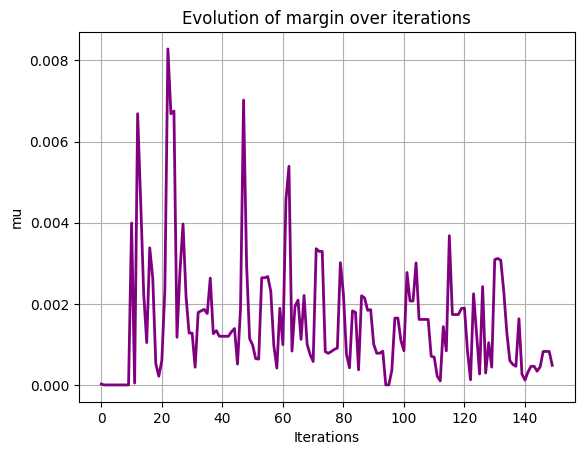

19:01:24 | INFO | machinemoo | Fit runtime: 9267.48 seconds


In [14]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

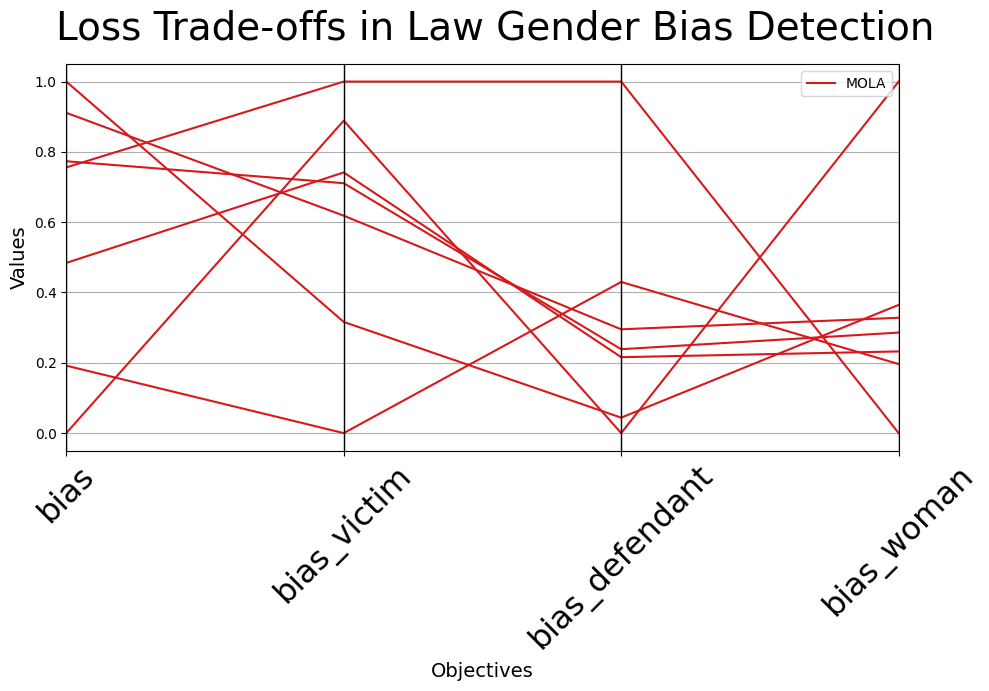

In [15]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_mola.pdf'
            )

19:01:26 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
19:01:26 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/2 - Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]
19:01:53 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]
19:02:20 | DEBUG | machinemoo | Finding 3th individual minimum
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.64s/it]
19:02:47 | DEBUG | machinemoo | Finding 4th individual minimum
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]
19:03:14 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -25.13709251  -64.726

new solution added [0.71022543 0.62452532 0.75600957 0.64335221]
solution dominated [0.71202857 0.65611117 0.78870252 0.71633508]


19:03:41 | DEBUG | machinemoo | Calculated weights: [0. 0. 0. 1.]
19:03:41 | DEBUG | machinemoo | Importance: 111.98572059869767
19:03:41 | DEBUG | machinemoo | Global lower bound (y*): [ -25.13709251  -63.70635903  -92.76416478 -111.9857206 ]
19:03:41 | DEBUG | machinemoo | Iteration 2
19:03:41 | DEBUG | machinemoo | Solutions list: [array([0.71022543, 0.62452532, 0.75600957, 0.64335221]), array([0.70945942, 0.62648857, 0.78492804, 0.71862737]), array([0.70827765, 0.6256621 , 0.75409974, 0.71806053]), array([0.71148881, 0.62703934, 0.75474086, 0.67579195])]
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.64s/it]
19:04:08 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -25.13709251  -64.04940478  -92.76416478 -111.9857206 ]


new solution added [0.71248499 0.62466749 0.75718644 0.60802171]


19:04:08 | DEBUG | machinemoo | Calculated weights: [0. 0. 0. 1.]
19:04:08 | DEBUG | machinemoo | Importance: 111.98572059869767
19:04:08 | DEBUG | machinemoo | Global lower bound (y*): [ -25.13709251  -64.04940478  -92.76416478 -111.9857206 ]
19:04:08 | DEBUG | machinemoo | Iteration 3
19:04:08 | DEBUG | machinemoo | Solutions list: [array([0.71248499, 0.62466749, 0.75718644, 0.60802171]), array([0.71022543, 0.62452532, 0.75600957, 0.64335221]), array([0.70945942, 0.62648857, 0.78492804, 0.71862737]), array([0.70827765, 0.6256621 , 0.75409974, 0.71806053]), array([0.71148881, 0.62703934, 0.75474086, 0.67579195])]
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.64s/it]
19:04:35 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -25.13709251  -64.04940478  -92.76416478 -111.9857206 ]


...

20:09:30 | DEBUG | machinemoo | Calculated weights: [0. 0. 1. 0.]
20:09:30 | DEBUG | machinemoo | Importance: 88.06821601390838
20:09:30 | DEBUG | machinemoo | Global lower bound (y*): [-18.68323048 -75.07117474 -87.72808752 -60.64896713]
20:09:30 | DEBUG | machinemoo | Iteration 148
20:09:30 | DEBUG | machinemoo | Solutions list: [array([0.70784589, 0.62675812, 0.35217365, 0.00274733]), array([0.70969018, 0.62582941, 0.35436553, 0.00277607]), array([0.71360682, 0.62796381, 0.3462476 , 0.00272941]), array([0.71070451, 0.6262904 , 0.34012849, 0.00283947]), array([0.70947796, 0.62533716, 0.3438894 , 0.00295588]), array([0.70985185, 0.62356178, 0.34585232, 0.00272959]), array([0.7084818 , 0.62506549, 0.34910997, 0.00279255]), array([0.70934643, 0.62300597, 0.36357018, 0.00279435]), array([0.70917009, 0.62603911, 0.36729358, 0.00273484]), array([0.7097699 , 0.62603469, 0.36006358, 0.00274679]), array([0.70861386, 0.62483311, 0.361559  , 0.00277681]), array([0.71081666, 0.62314383, 0.372508

new solution added [0.70894678 0.6266772  0.34589886 0.00274045]


20:09:57 | DEBUG | machinemoo | Calculated weights: [0. 0. 1. 0.]
20:09:57 | DEBUG | machinemoo | Importance: 88.06821601390838
20:09:57 | DEBUG | machinemoo | Global lower bound (y*): [-18.68323048 -75.07117474 -87.72808752 -60.64896713]
20:09:57 | DEBUG | machinemoo | Iteration 149
20:09:57 | DEBUG | machinemoo | Solutions list: [array([0.70894678, 0.6266772 , 0.34589886, 0.00274045]), array([0.70784589, 0.62675812, 0.35217365, 0.00274733]), array([0.70969018, 0.62582941, 0.35436553, 0.00277607]), array([0.71360682, 0.62796381, 0.3462476 , 0.00272941]), array([0.71070451, 0.6262904 , 0.34012849, 0.00283947]), array([0.70947796, 0.62533716, 0.3438894 , 0.00295588]), array([0.70985185, 0.62356178, 0.34585232, 0.00272959]), array([0.7084818 , 0.62506549, 0.34910997, 0.00279255]), array([0.70934643, 0.62300597, 0.36357018, 0.00279435]), array([0.70917009, 0.62603911, 0.36729358, 0.00273484]), array([0.7097699 , 0.62603469, 0.36006358, 0.00274679]), array([0.70861386, 0.62483311, 0.361559

new solution added [0.70873096 0.62610072 0.35596541 0.00276975]


20:10:24 | DEBUG | machinemoo | Calculated weights: [0. 0. 1. 0.]
20:10:24 | DEBUG | machinemoo | Importance: 88.06821601390838
20:10:24 | DEBUG | machinemoo | Global lower bound (y*): [-18.68323048 -75.07117474 -87.72808752 -60.64896713]
20:10:24 | DEBUG | machinemoo | Iteration 150
20:10:24 | DEBUG | machinemoo | Solutions list: [array([0.70873096, 0.62610072, 0.35596541, 0.00276975]), array([0.70894678, 0.6266772 , 0.34589886, 0.00274045]), array([0.70784589, 0.62675812, 0.35217365, 0.00274733]), array([0.70969018, 0.62582941, 0.35436553, 0.00277607]), array([0.71360682, 0.62796381, 0.3462476 , 0.00272941]), array([0.71070451, 0.6262904 , 0.34012849, 0.00283947]), array([0.70947796, 0.62533716, 0.3438894 , 0.00295588]), array([0.70985185, 0.62356178, 0.34585232, 0.00272959]), array([0.7084818 , 0.62506549, 0.34910997, 0.00279255]), array([0.70934643, 0.62300597, 0.36357018, 0.00279435]), array([0.70917009, 0.62603911, 0.36729358, 0.00273484]), array([0.7097699 , 0.62603469, 0.360063

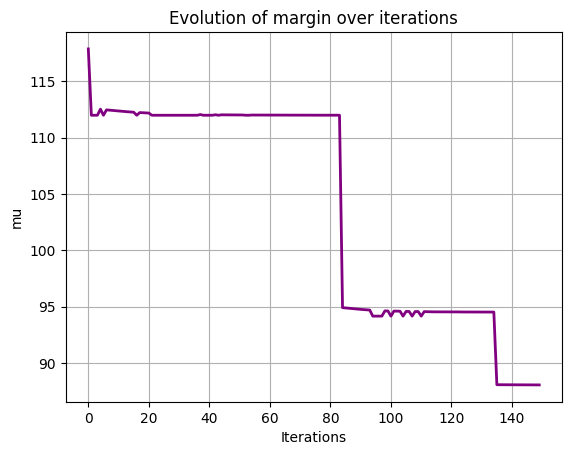

20:10:24 | INFO | machinemoo | Fit runtime: 4138.42 seconds


In [16]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

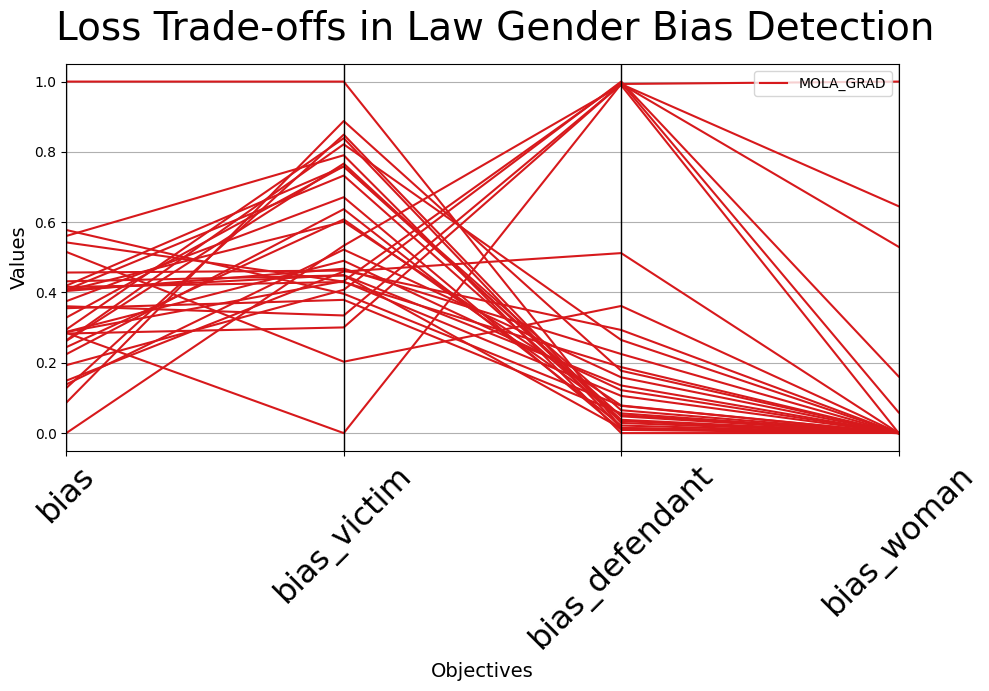

In [17]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'mola_grad': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_mola_grad.pdf'
            )

### Random Weights

In [18]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

20:10:26 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'nodeGap', 'targetGap'}
20:10:26 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
20:10:26 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/2 - Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]
20:10:53 | DEBUG | machinemoo | Finding 2th individual minima
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]
20:11:20 | DEBUG | machinemoo | Finding 3th individual minima
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]
20:11:47 | DEBUG | machinemoo | Finding 4th individual minima
Evaluating: 100%|██████████| 5/5 [00:08<00:00,  1.64s/it]
20:12:41 | DEBUG | machinemoo | 

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [19]:
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes

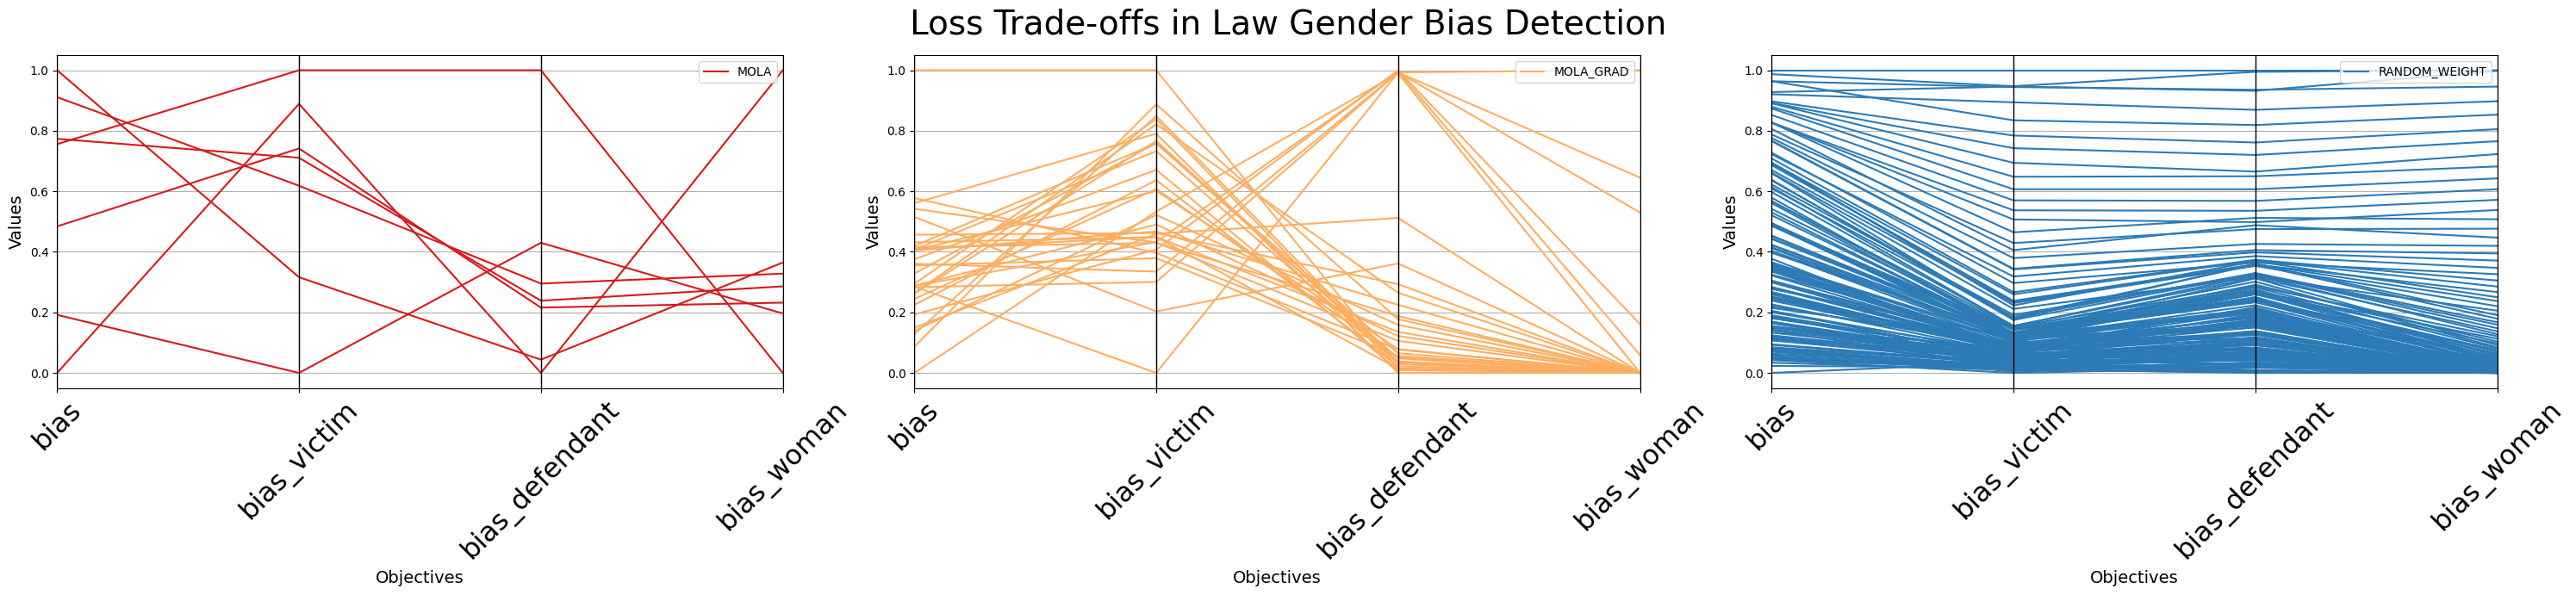

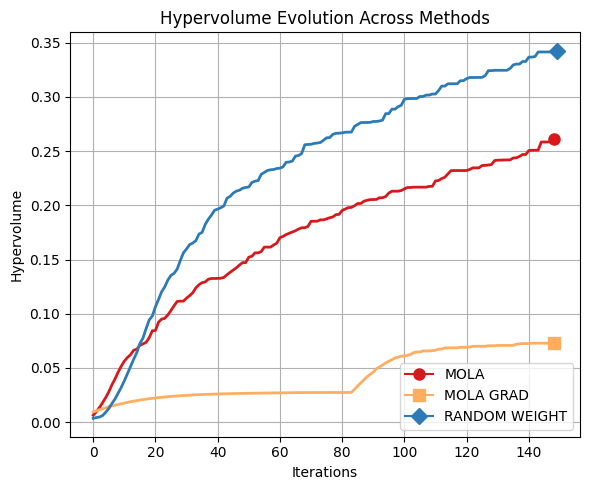

In [20]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)